# **PROYECTO: FUNDAMENTOS MATEMÁTICOS**

Una vez visto el ***Módulo 2: Fundamentos Matemáticos***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **análisis exploratorio con aprendizaje estadístico** de cualquier dataset proveniente de la librería de ***Seaborn*** que no haya sido utilizado.

Se sugiere los siguientes puntos para llevar a cabo lo anterior:

*   Realizar un **análisis descriptivo** para comprender comportamiento de la descripción de los datos a través de resúmenes.
*   Realizar un **aprendizaje estadístico** para predecir comportamientos lineales de datos a través de la regresión lineal simple.

In [1]:
#Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Dataset: "Diamonds"
df_diamonds = sns.load_dataset('diamonds')
df_diamonds.index += 1
df_diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [3]:
#1.1. Análisis Univariable.
#Propiedades de la tabla
df_diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 1 to 53940
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [4]:
#Resumen estadístico
df_diamonds.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [5]:
#Medidas de tendencia central (MTC)

media = round(df_diamonds['carat'].mean(),2)
mediana = round(df_diamonds['carat'].median(),2)
moda = df_diamonds['carat'].mode().iloc[0]

print(f'La media es: {media}')
print(f'La mediana es: {mediana}')
print(f'La moda es: {moda}')

La media es: 0.8
La mediana es: 0.7
La moda es: 0.3


In [6]:
#Desviación estandar
std = round(df_diamonds.describe()['carat']['std'], 4)
print(f'La desviación estándar es: {std}')

#La proporcion de probailidad
prop_prob = round((std /media)*100 , 1) # Es más comodo verlo en porcentaje
print(f'Los datos se separan de la media a un: {prop_prob}%')

La desviación estándar es: 0.474
Los datos se separan de la media a un: 59.2%


In [7]:
#Medidas de disperción
x= range(len(df_diamonds['carat']))
y= df_diamonds['carat']

print(x)
print(y)

std = np.std(df_diamonds['carat'])
print(f'La desviación estandar es de: {round(std, 2)}')

range(0, 53940)
1        0.23
2        0.21
3        0.23
4        0.29
5        0.31
         ... 
53936    0.72
53937    0.72
53938    0.70
53939    0.86
53940    0.75
Name: carat, Length: 53940, dtype: float64
La desviación estandar es de: 0.47


In [8]:
#Percentiles y rango intercuartílico(IQR)

percentil = np.percentile(df_diamonds['carat'],[25,50,75])
print(percentil)

q_1 = round(percentil[0],2)
q_3 = round(percentil[2], 2)
print(q_1)
print(q_3)

iqr = q_3 - q_1
print(f'El valor intercuartílico es de: {iqr}')

[0.4  0.7  1.04]
0.4
1.04
El valor intercuartílico es de: 0.64


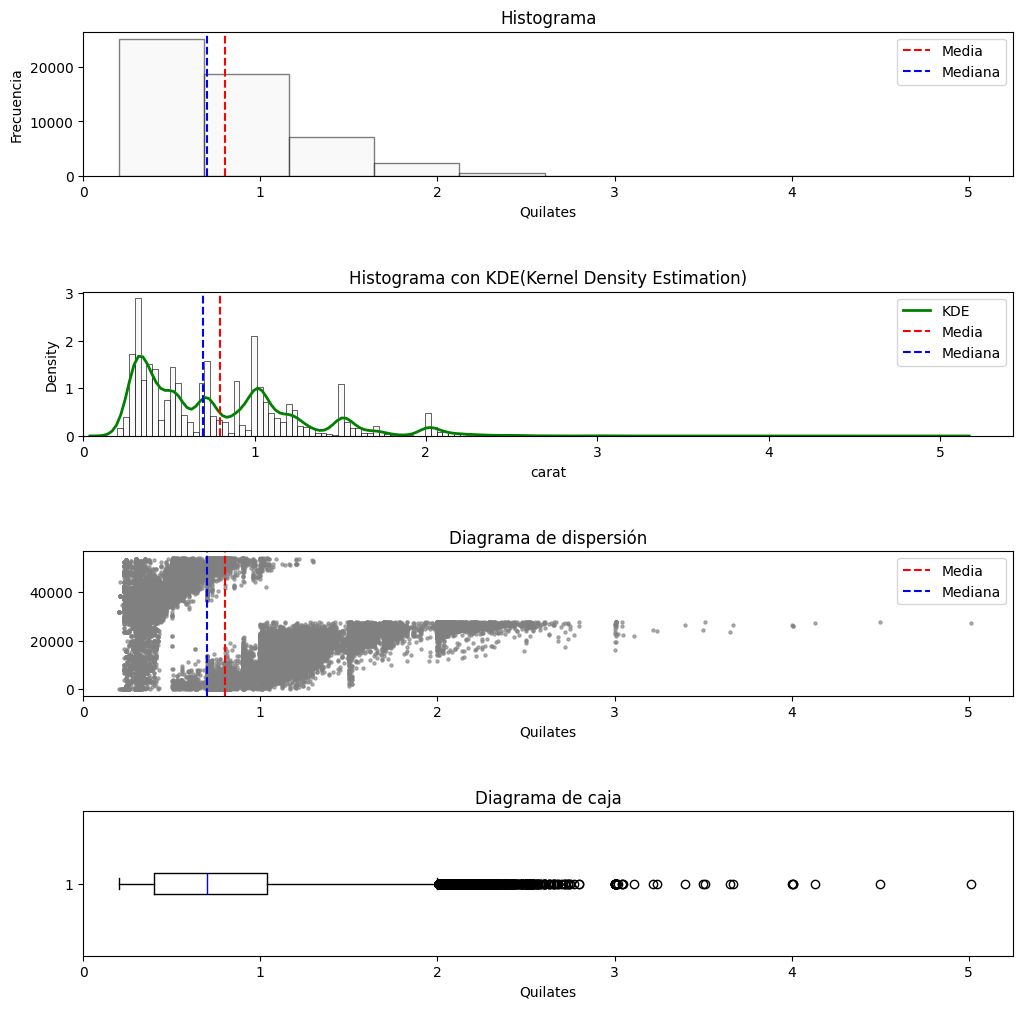

In [9]:
#Visualización de medidas descriptivas

fig, ax = plt.subplots(4, figsize =(12,12), gridspec_kw = {'hspace': 0.8})

ax[0].hist(df_diamonds['carat'], edgecolor ='black',color = 'whitesmoke', alpha = 0.5)
ax[0].axvline(media, color= 'red', linestyle= '--', label = 'Media')
ax[0].axvline(mediana, color= 'blue', linestyle= '--', label = 'Mediana')
ax[0].set_xlim(0)
ax[0].set_title('Histograma')
ax[0].set_xlabel('Quilates')
ax[0].set_ylabel('Frecuencia')
ax[0].legend()

sns.histplot(df_diamonds['carat'], kde=True, stat="density", color='whitesmoke', edgecolor='black', ax=ax[1])
sns.kdeplot( data=df_diamonds, x='carat', color='green', linewidth=2 , ax=ax[1], label= 'KDE')
ax[1].set_title('Histograma con KDE(Kernel Density Estimation)')
ax[1].axvline(media, color= 'red', linestyle= '--', label = 'Media')
ax[1].axvline(mediana, color= 'blue', linestyle= '--', label = 'Mediana')
ax[1].set_xlim(0)
ax[1].legend()

ax[2].scatter(y, x, s=5 , color= 'gray', alpha = 0.6)
ax[2].set_title('Diagrama de dispersión')
ax[2].axvline(media, color= 'red', linestyle= '--', label = 'Media')
ax[2].axvline(mediana, color= 'blue', linestyle= '--', label = 'Mediana')
ax[2].set_xlabel('Quilates')
ax[2].set_xlim(0)
ax[2].legend(loc= 'upper right')

ax[3].boxplot(df_diamonds['carat'],vert=False, medianprops={'color': 'blue'})
ax[3].set_title('Diagrama de caja')
ax[3].set_xlabel('Quilates')
ax[3].set_xlim(0)

plt.show()

In [10]:
df_diamonds[df_diamonds['carat']> 5]


,carat,cut,color,clarity,depth,table,price,x,y,z
27416,5.01,Fair,J,I1,65.5,59.0,18018,10.74,10.54,6.98


In [11]:
#1.2. Análisis multivariable
columnas = ['carat','depth','z','price']
corr = df_diamonds[columnas].corr()
long_col = len(columnas)
print(corr)


          carat     depth         z     price
carat  1.000000  0.028224  0.953387  0.921591
depth  0.028224  1.000000  0.094924 -0.010647
z      0.953387  0.094924  1.000000  0.861249
price  0.921591 -0.010647  0.861249  1.000000


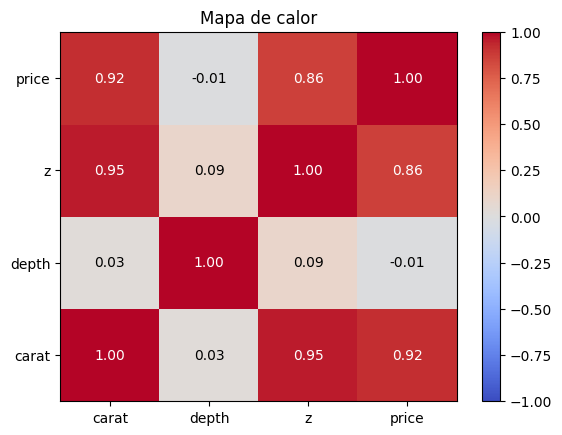

In [12]:
#Visualización mapa de calor

heatmap = plt.pcolor(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Mapa de calor')

plt.xticks(np.arange(0.5, long_col, 1), columnas)
plt.yticks(np.arange(0.5, long_col, 1), columnas)

for i in range(len(columnas)):
    for j in range(len(columnas)):
        plt.text(j + 0.5, i + 0.5, f'{corr.iloc[i,j]:.2f}',
                 ha= 'center', va= 'center',
                 color= 'white' if abs(corr.iloc[i,j])> 0.6 else 'black')
plt.colorbar()
plt.show()

In [13]:
#1.3. Análisis Bivariable
#Correlación de Pearson

corr_carat_price = round(df_diamonds['carat'].corr(df_diamonds['price']), 2)
corr_carat_z = round(df_diamonds['carat'].corr(df_diamonds['z']), 2)
corr_z_price = round(df_diamonds['z'].corr(df_diamonds['price']), 2)

print(f'La correlación entre los quilates y el precio es de: {corr_carat_price}')
print(f'La correlación entre los quilates y la dimension del diamante(z) :{corr_carat_z}')
print(f'La correlación entre la dimensión del diamante(z) y el precio: {corr_z_price}')

La correlación entre los quilates y el precio es de: 0.92
La correlación entre los quilates y la dimension del diamante(z) :0.95
La correlación entre la dimensión del diamante(z) y el precio: 0.86


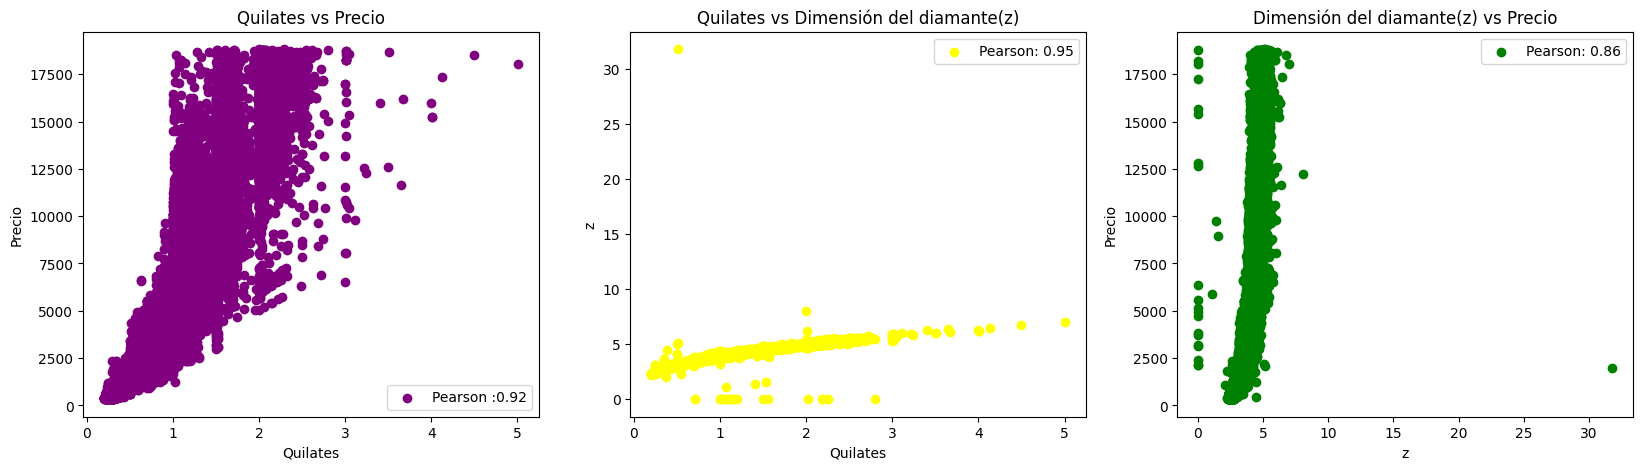

In [14]:
#Visualización de las correlaciones

fig, ax = plt.subplots(1,3, figsize=(20,5))

ax[0].scatter(data = df_diamonds, x='carat', y='price', color='purple' ,label=f'Pearson :{corr_carat_price}' )
ax[0].set_title('Quilates vs Precio')
ax[0].set_xlabel('Quilates')
ax[0].set_ylabel('Precio')
ax[0].legend(loc='lower right')

ax[1].scatter(data = df_diamonds, x= 'carat', y='z', color='yellow' , label= f'Pearson: {corr_carat_z}')
ax[1].set_title('Quilates vs Dimensión del diamante(z)')
ax[1].set_xlabel('Quilates')
ax[1].set_ylabel('z')
ax[1].legend(loc='upper right')

ax[2].scatter(data = df_diamonds, x= 'z', y='price', color='green' , label= f'Pearson: {corr_z_price}')
ax[2].set_title('Dimensión del diamante(z) vs Precio')
ax[2].set_xlabel('z')
ax[2].set_ylabel('Precio')
ax[2].legend(loc='upper right')

plt.show()

## Prueba de Hipotesis

In [16]:
from scipy import stats

In [17]:
df_diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [18]:
#Nivel de significancia
#Separación de grupos
cut_Ideal = df_diamonds[df_diamonds['cut'] == 'Ideal']['price']
cut_Premium = df_diamonds[df_diamonds['cut'] == 'Premium']['price']

In [19]:
#Prueba T de Student

t_stat, p_value = stats.ttest_ind(cut_Ideal,cut_Premium)

print('t-satistic: ',round(t_stat,2))
print('p-value: ', round(p_value,2))

t-satistic:  -25.65
p-value:  0.0


In [20]:
#Interpretación automática

if p_value < 0.01 :
    print('\nConclusión: Rechazámos la Hipótesis Nula.')
    print('Existe una diferencia muy significativa entre el precio de ambos grupos')
elif p_value > 0.01 and p_value < 0.05:
    print('\nConclusión: Rechazámos la Hipótesis Nula.')
    print('Existe una diferencia altamente significativa entre el precio de ambos grupos')
elif p_value > 0.05 and p_value < 0.10:
    print('\nConclusión: Rechazámos la Hipótesis Nula.')
    print('Existe una diferencia moderamente significativa entre el precio de ambos grupos')
else:
    print('\nConclusión: No podemos rechazar la Hipótesis Nula.')
    print('No hay evidencia suficiente para decir que el precio es diferente para los cortes ideal y premium')



Conclusión: Rechazámos la Hipótesis Nula.
Existe una diferencia muy significativa entre el precio de ambos grupos


## 2. Aprendizaje Estadístico

In [21]:
#Regresión lineal simple: Predicción del precio en función de los quilates del diamante.

x= df_diamonds['carat']
y= df_diamonds['price']

linear_regression = np.polyfit(x, y, 1)
beta, alpha = linear_regression

print(f'y={beta}x + {alpha}')

y=7756.425617968436x + -2256.3605800454043


In [22]:
#Parametro
tamano_step= 0.001
theta_0 = 0
theta_1 =0
perdida = []

In [23]:
#Algoritmo de optimización del descenso de gradiante.
num_iteraciones = 100

for i in range(num_iteraciones):
    y_pred = theta_1 * x + theta_0
    error = ((y-y_pred)**2).mean()
    perdida.append(error)

    d_theta_0 = (2/len(x)) * np.sum(y_pred - y)
    d_theta_1 = (2/len(x)) * np.sum((y_pred - y)* x)

    theta_0 = theta_0 - tamano_step * d_theta_0
    theta_1 = theta_1 - tamano_step * d_theta_1

print(f'y={theta_1}x +{theta_0}')

y=845.7758433021693x +647.8869954118268


In [24]:
#Predicción de valores con descenso de gradiante

try:
    tb_pred_gr_diamond = float(input('Ingrese los quilates que desea predecir el precio: ').strip())
    y_pred_gr_diamond = round(theta_1 * tb_pred_gr_diamond +theta_0, 2)

    print(f'El precio predicho para un quilate de {tb_pred_gr_diamond} es de ${y_pred_gr_diamond}')

except:
    print('Intente nuevamente con un número')

Ingrese los quilates que desea predecir el precio: 0.11
El precio predicho para un quilate de 0.11 es de $740.92


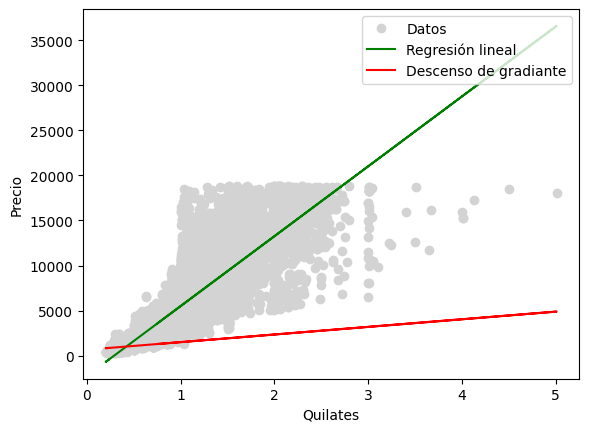

In [25]:
#Visualización de regresiones

plt.plot(x, y, 'o', color= 'lightgrey', label ='Datos')
plt.plot(x, beta * x + alpha, color = 'green', label = 'Regresión lineal')
plt.plot(x, theta_1 * x + theta_0, color = 'red', label = 'Descenso de gradiante')
plt.xlabel('Quilates')
plt.ylabel('Precio')
plt.legend(loc='upper right')
plt.show()


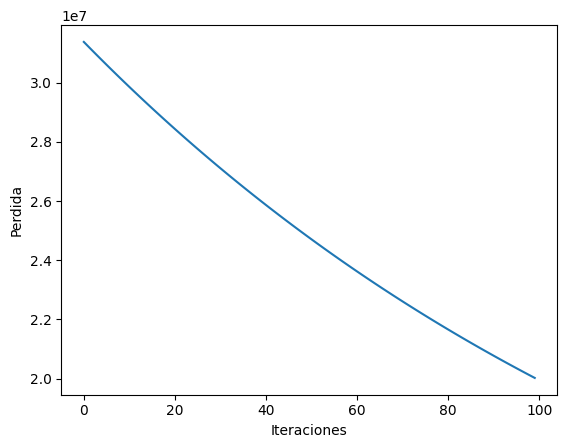

In [26]:
#Visualización de la función costo

plt.plot(perdida)
plt.xlabel('Iteraciones')
plt.ylabel('Perdida')
plt.show()